In [ ]:
!pip uninstall -y torch torchvision torchaudio nvidia-pyindex nvidia-pip


Found existing installation: torch 2.8.0+cu126
Uninstalling torch-2.8.0+cu126:
  Successfully uninstalled torch-2.8.0+cu126
Found existing installation: torchvision 0.23.0+cu126
Uninstalling torchvision-0.23.0+cu126:
  Successfully uninstalled torchvision-0.23.0+cu126
Found existing installation: torchaudio 2.8.0+cu126
Uninstalling torchaudio-2.8.0+cu126:
  Successfully uninstalled torchaudio-2.8.0+cu126


In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126


Looking in indexes: https://download.pytorch.org/whl/cu126
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.8/821.8 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 119.4 MB/s eta 0:00:00


In [ ]:
!pip install transformers datasets scikit-learn numpy pandas tqdm matplotlib tensorboard


In [ ]:
!nvidia-smi

Tue Oct  7 13:29:04 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             45W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
import torch

# Kiểm tra GPU
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

# Tạo tensor lớn trên GPU để test
x = torch.randn(10000, 10000, device="cuda")
print("Tensor on:", x.device)


CUDA available: True
GPU count: 1
GPU name: NVIDIA A100-SXM4-40GB
Tensor on: cuda:0


In [ ]:
import torch
torch.cuda.is_available()

True

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())

Torch version: 2.8.0+cu126
CUDA available: True
Device count: 1


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
import sys
from google.colab import drive

# Gắn kết Google Drive
drive.mount('/content/drive')
# Đường dẫn thư mục dữ liệu
data_dir = '/content/drive/MyDrive/ViHOS_VN/data/fulldata'
print("hello",sys.argv)

if len(sys.argv) <= 2 or sys.argv[1] not in ['all', 'single', 'multi']:
    sys.argv = [sys.argv[0], 'all', 'word']
    print('Using default arguments: dataset=all, mode=word')
else:
    if len(sys.argv) <= 2:
        sys.argv += ['word']
    print('Usage: python trainv3.py dataset(all, single, multi) mode(word, syllable)')
    #exit()

is_word = sys.argv[2] == 'word'
testing = False
if len(sys.argv) >=4:
    testing = sys.argv[3] == 'testing'
dbname = sys.argv[1]
print('dbname:', dbname)
if dbname not in ['all', 'single', 'multi']:
    print('dataset must be one of values [all, single, multi]')
    #exit()
if dbname == 'all':
    dbname = 'fulldata'
model_size = '-large'
print('Run', 'testing' if testing else 'release', dbname, 'word' if is_word else 'syllable')
model_name = "vinai/phobert" + model_size

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
hello ['/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py', '-f', '/root/.local/share/jupyter/runtime/kernel-ec79ec0c-914c-4de4-a160-b9f97afa6aea.json']
Using default arguments: dataset=all, mode=word
dbname: all
Run release fulldata word


In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer
from sklearn.metrics import f1_score
import pickle
import torch
import torch.nn as nn
from sklearn.metrics import precision_score, recall_score, f1_score
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np
from transformers import (
    AutoModel, AutoConfig, XLMRobertaModel,
    AutoTokenizer, AutoModelForSequenceClassification, AutoModelForCausalLM,
     AutoModelForTokenClassification
)
from ast import literal_eval
import pandas as pd
from tqdm import tqdm
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
import random

In [ ]:
layout = {
    "Hated-Span": {
        "loss": ["Multiline", ["loss/train", "loss/validation"]],
        "accuracy": ["Multiline", ["accuracy/train", "accuracy/validation"]],
        "f1": ["Multiline", ["f1/train", "f1/validation"]],
        "precision": ["Multiline", ["precision/train", "precision/validation"]],
        "recall": ["Multiline", ["recall/train", "recall/validation"]],
        "wf1": ["Multiline", ["wf1/train", "wf1/validation"]],
        "wprecision": ["Multiline", ["wprecision/train", "wprecision/validation"]],
        "wrecall": ["Multiline", ["wrecall/train", "wrecall/validation"]],
    },
}

writers = []
model_names = ['m1', 'm2', 'm3']
for mname in ['m1', 'm2', 'm3', 'total']:
    loggerpath = f"phobertbootstrap/{mname}-{dbname}-{'word' if is_word else 'syllable'}{model_size}"
    if os.path.isdir(loggerpath):
        stt = 1
        while os.path.isdir(f'{loggerpath}-{stt}'):
            stt += 1
        loggerpath = f'{loggerpath}-{stt}'
    writer = SummaryWriter(loggerpath)
    writer.add_custom_scalars(layout)
    writers.append(writer)

totalwriter = writers[-1]
writers = writers[:-1]
torch.cuda.empty_cache()

Định nghĩa các hàm để lấy đường dẫn dữ liệu

In [ ]:
def get_paths(dbname, type="input_ids", basepath='.', model_size='-large'):
    return f'{basepath}/{dbname}/train.csv{model_size}-{type}.csv', f'{basepath}/{dbname}/dev.csv{model_size}-{type}.csv', f'{basepath}/{dbname}/test.csv{model_size}-{type}.csv'

def get_paths_word(dbname, type="input_ids", basepath='.', model_size='-large'):
    return f'{basepath}/{dbname}/train.csv{model_size}-{type}-word.csv', f'{basepath}/{dbname}/dev.csv{model_size}-{type}-word.csv', f'{basepath}/{dbname}/test.csv{model_size}-{type}-word.csv'

get_data_paths = get_paths_word if is_word else get_paths
train_path, dev_path, test_path = get_data_paths(dbname, basepath='./data')
print('train_path:',train_path)

train_path: ./data/fulldata/train.csv-large-input_ids-word.csv


In [ ]:
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, input_ids, labels, tokenizer, max_len):
        self.input_ids = []
        self.labels = []
        self.attention_mask = []
        for input_id in input_ids:
            if len(input_id) < max_len:
                self.input_ids.append(input_id + [1] * (max_len - len(input_id)))
                self.attention_mask.append([1] * len(input_id) + [0] * (max_len - len(input_id)))
            else:
                self.input_ids.append(input_id[:max_len-1] + [2])
                self.attention_mask.append([1] * max_len)

        for span in labels:
            if len(span) < max_len:
                self.labels.append(span + [0] * (max_len - len(span)))
            else:
                self.labels.append(span[:max_len-1] + [0])

        self.labels = torch.tensor(self.labels)
        self.input_ids = torch.tensor(self.input_ids)
        self.attention_mask = torch.tensor(self.attention_mask)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return self.input_ids[index], self.attention_mask[index], self.labels[index]

Định nghĩa hàm tạo DataLoader

In [ ]:
def create_dataloader(input_ids, labels, batch_size, tokenizer, max_len, shuffle=True, bootstrap=False):
    dataset = TextDataset(input_ids, labels, tokenizer, max_len)
    if bootstrap:
        subset_size = int(bootstrap * len(dataset))
        def create_random_subset(dataset, subset_size):
            indices = random.sample(range(len(dataset)), subset_size)
            return Subset(dataset, indices)
        subset1 = torch.utils.data.DataLoader(create_random_subset(dataset, subset_size), batch_size=batch_size, shuffle=shuffle)
        subset2 = torch.utils.data.DataLoader(create_random_subset(dataset, subset_size), batch_size=batch_size, shuffle=shuffle)
        subset3 = torch.utils.data.DataLoader(create_random_subset(dataset, subset_size), batch_size=batch_size, shuffle=shuffle)
        return subset1, subset2, subset3
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    return dataloader

Phần 8: Định nghĩa hàm chuẩn bị dữ liệu

In [ ]:
def prepare_data(file_path):
    global testing
    df = pd.read_csv(file_path)
    df = df.dropna()
    df = df.reset_index(drop=True)
    df.input_ids = df.input_ids.apply(literal_eval)
    df.labels = df.labels.apply(literal_eval)
    input_ids = df['input_ids'].tolist()
    labels = df['labels'].tolist()
    if testing:
        return input_ids[:500], labels[:500]
    return input_ids, labels

Phần 9: Định nghĩa lớp mô hình PhoBERTTokenClassifier

In [ ]:
class PhoBERTTokenClassifier(nn.Module):
    def __init__(self, model_name=model_name):
        super(PhoBERTTokenClassifier, self).__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.fc = nn.Sequential(
            nn.Linear(768 if model_size == '-base' else 1024, 512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 1),
        )

    def forward(self, input_ids, attention_mask):
        output = self.bert(input_ids=input_ids, attention_mask=attention_mask, return_dict=False)
        last_hidden_state = output[0]
        span_logits = self.fc(last_hidden_state)
        span_logits = span_logits.permute(0, 2, 1)
        span_logits = torch.sigmoid(span_logits)
        span_logits = span_logits.permute(0, 2, 1)
        return span_logits.squeeze(-1)

Phần 10: Khởi tạo mô hình và các tham số

In [ ]:
# Các import cần thiết
import os
import sys
import torch
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer
import random

# Định nghĩa các hàm và lớp cần thiết ở đây
# ...

# Kiểm tra model
if __name__ == "__main__":
    # Thiết lập các tham số đầu vào
    dbname = 'all'  # Hoặc 'single' hoặc 'multi'
    is_word = True  # Hoặc False nếu bạn muốn sử dụng 'syllable'
    testing = False  # Thay đổi thành True nếu bạn muốn chạy chế độ testing

    if dbname not in ['all', 'single', 'multi']:
        print('dataset must be one of values [all, single, multi]')
        exit()

    if dbname == 'all':
        dbname = 'fulldata'

    model_size = '-large'
    print('Run', 'testing' if testing else 'release', dbname, 'word' if is_word else 'syllable')
    model_name = "vinai/phobert" + model_size

    # Đường dẫn tuyệt đối cho các file dữ liệu
    data_dir = '/content/drive/MyDrive/ViHOS_VN/data/fulldata'  # Thay đổi đường dẫn này nếu cần
    train_path = os.path.join(data_dir, 'train.csv-large-input_ids-word.csv')
    dev_path = os.path.join(data_dir, 'dev.csv-large-input_ids-word.csv')
    test_path = os.path.join(data_dir, 'test.csv-large-input_ids-word.csv')

    # Kiểm tra sự tồn tại của các file
    print("Checking if train file exists:", os.path.exists(train_path))
    print("Checking if dev file exists:", os.path.exists(dev_path))
    print("Checking if test file exists:", os.path.exists(test_path))

    # Nếu tất cả các file tồn tại, tiếp tục
    if os.path.exists(train_path) and os.path.exists(dev_path) and os.path.exists(test_path):
        # Khởi tạo tokenizer
        tokenizer = AutoTokenizer.from_pretrained(model_name)

        # Khởi tạo model
        model1 = PhoBERTTokenClassifier()
        model2 = PhoBERTTokenClassifier()
        model3 = PhoBERTTokenClassifier()

        # Set the number of epochs and the device to use for training
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model1.to(device)
        model2.to(device)
        model3.to(device)

        optimizer_spans1 = optim.Adam(list(model1.parameters()), lr=5e-6, weight_decay=1e-5)
        optimizer_spans2 = optim.Adam(list(model2.parameters()), lr=5e-6, weight_decay=1e-5)
        optimizer_spans3 = optim.Adam(list(model3.parameters()), lr=5e-6, weight_decay=1e-5)

        print('Loading data')
        batch_size = 128
        train_dataloader1, train_dataloader2, train_dataloader3 = create_dataloader(*prepare_data(train_path), batch_size=batch_size, tokenizer=tokenizer, max_len=64, bootstrap=0.7)
        dev_dataloader = create_dataloader(*prepare_data(dev_path), batch_size=batch_size, tokenizer=tokenizer, max_len=64, shuffle=False)
        test_dataloader = create_dataloader(*prepare_data(test_path), batch_size=batch_size, tokenizer=tokenizer, max_len=64)

        result_path = f'./results-bootstrap-{"word" if is_word else "syllable"}/' + dbname
        if not os.path.isdir(result_path):
            os.makedirs(result_path, exist_ok=True)

        model_logged = False  # chưa vẽ model vào tensorboard
        print('Done')

        # Định nghĩa mode
        mode = 'word' if is_word else 'syllable'  # Định nghĩa mode ở đây


    else:
        print("One or more files do not exist. Please check the paths and try again.")

Run release fulldata word
Checking if train file exists: False
Checking if dev file exists: False
Checking if test file exists: False
One or more files do not exist. Please check the paths and try again.


Phần 11: Định nghĩa hàm tính toán điểm số

In [ ]:
def calc_scores(writer, span_targets, span_preds, epoch, mode='train'):
    span_preds = np.concatenate(span_preds)
    span_targets = np.concatenate(span_targets)
    span_preds = (span_preds > 0.5).astype(int)
    vals = classification_report(span_targets, span_preds, output_dict=True)
    writer.add_scalar("accuracy/" + mode, vals['accuracy'], epoch)
    writer.add_scalar("f1/" + mode, vals['macro avg']['f1-score'], epoch)
    writer.add_scalar("precision/" + mode, vals['macro avg']['precision'], epoch)
    writer.add_scalar("recall/" + mode, vals['macro avg']['recall'], epoch)
    writer.add_scalar("wf1/" + mode, vals['weighted avg']['f1-score'], epoch)
    writer.add_scalar("wprecision/" + mode, vals['weighted avg']['precision'], epoch)
    writer.add_scalar("wrecall/" + mode, vals['weighted avg']['recall'], epoch)

    # Add print statements for better visibility in console
    print(f"Mode: {mode}, Epoch: {epoch}")
    print(f"  Accuracy: {vals['accuracy']:.4f}")
    print(f"  Macro Avg F1: {vals['macro avg']['f1-score']:.4f}, Precision: {vals['macro avg']['precision']:.4f}, Recall: {vals['macro avg']['recall']:.4f}")
    print(f"  Weighted Avg F1: {vals['weighted avg']['f1-score']:.4f}, Precision: {vals['weighted avg']['precision']:.4f}, Recall: {vals['weighted avg']['recall']:.4f}")

    return vals

Phần 12: Định nghĩa hàm huấn luyện một epoch

In [ ]:
def train_1epoch(name, model, train_dataloader, optimizer_span, device, writer, stt, total_epochs):
    global model_logged, mode
    criterion_span = nn.BCELoss()
    model.train()
    total_loss = 0
    span_preds = []
    span_targets = []
    print(name + ' Epoch: ', f'{stt}/{total_epochs}, mode {mode}')
    for input_ids, attention_mask, spans in tqdm(train_dataloader):
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        spans = spans.float().to(device)
        optimizer_span.zero_grad()
        if not model_logged:
            writer.add_graph(model, [input_ids, attention_mask])
            model_logged = True
        span_logits = model(input_ids, attention_mask)
        loss_span = criterion_span(span_logits, spans)
        loss = loss_span
        loss.backward()
        optimizer_span.step()
        total_loss += loss.item()
        span_preds.append(span_logits.cpu().detach().numpy().flatten())
        span_targets.append(spans.cpu().detach().numpy().flatten())
    total_loss = total_loss / len(train_dataloader)
    writer.add_scalar("loss/train", total_loss, stt)
    calc_scores(writer, span_targets, span_preds, stt, mode='train')

    model.eval()
    val_loss = 0
    val_span_preds = []
    val_span_targets = []
    for input_ids, attention_mask, spans in tqdm(dev_dataloader):
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        spans = spans.float().to(device)
        with torch.no_grad():
            span_logits = model(input_ids, attention_mask)
            loss_span = criterion_span(span_logits, spans)
            val_loss += loss_span

        val_span_preds.append(span_logits.cpu().numpy().flatten())
        val_span_targets.append(spans.cpu().numpy().flatten())

    calc_scores(writer, val_span_targets, val_span_preds, stt, mode='validation')
    val_loss = val_loss / len(dev_dataloader)
    writer.add_scalar("loss/validation", val_loss, stt)
    return span_targets, span_preds, val_span_preds, val_span_targets

Phần 13: Định nghĩa hàm huấn luyện tất cả các mô hình

In [ ]:
def train_all(models, dataloaders, optimizer_spans, writes, model_names, num_epochs=3):
    criterion_span = nn.BCELoss()
    test_f1s = []
    for epoch in range(num_epochs):
        stt = epoch + 1
        trainspan_preds = []
        trainspan_targets = []
        val_span_preds = []
        val_span_targets = []
        for model, dataloader, writer, name, optimizer_span in zip(models, dataloaders, writes, model_names, optimizer_spans):
            span_targets, span_preds, val_span_pred, val_span_target = train_1epoch(name, model, dataloader, optimizer_span, device, writer, stt, num_epochs)
            span_preds = np.concatenate(span_preds)
            span_targets = np.concatenate(span_targets)
            trainspan_preds.append(span_preds)
            trainspan_targets.append(span_targets)
            val_span_pred = np.concatenate(val_span_pred)
            val_span_target = np.concatenate(val_span_target)
            val_span_preds.append(val_span_pred)
            val_span_targets.append(val_span_target)

        calc_scores(totalwriter, trainspan_targets, trainspan_preds, stt, mode='train')
        calc_scores(totalwriter, val_span_targets, val_span_preds, stt, mode='validation')
        span_preds = np.concatenate(trainspan_preds)
        span_targets = np.concatenate(trainspan_targets)
        span_preds = torch.tensor(span_preds).to(device)
        span_targets = torch.tensor(span_targets).to(device)
        total_loss_span = criterion_span(span_preds, span_targets).item() / (3 * len(dataloaders[0]))
        totalwriter.add_scalar("loss/train", total_loss_span, stt)

        span_preds = np.concatenate(val_span_preds)
        span_targets = np.concatenate(val_span_targets)
        span_preds = torch.tensor(span_preds).to(device)
        span_targets = torch.tensor(span_targets).to(device)
        val_total_loss_span = criterion_span(span_preds, span_targets).item() / (3 * len(dataloaders[0]))
        totalwriter.add_scalar("loss/validation", val_total_loss_span, stt)

        test_f1, test_precision, test_recall, test_span_preds, test_span_targets, tokens, total_loss = test(models, test_dataloader, device)
        if epoch == 22 or (test_f1s and test_f1 > max(test_f1s)):
            for model, name in zip(models, model_names):
                torch.save(model.state_dict(), f'{result_path}/{mode}-{name}-model{model_size}-{epoch}.pt')
            with open(f'{result_path}/{mode}-test-{model_size}-{epoch}.pkl', 'wb') as frs:
                pickle.dump({'span_preds': test_span_preds, 'span_targets': test_span_targets, 'tokens': tokens, 'total_loss': total_loss}, frs)

        test_f1s.append(test_f1)
        with open(f'{result_path}/{mode}test-f1s.txt', 'a+') as frs:
            frs.write(f'epoch: {epoch}, test_f1: {test_f1}, test_precision: {test_precision}, test_recall: {test_recall}\n')

Phần 14: Định nghĩa hàm huấn luyện

In [ ]:
def do_train(num_epochs=3):
    train_all([model1, model2, model3], [train_dataloader1, train_dataloader2, train_dataloader3], [optimizer_spans1, optimizer_spans2, optimizer_spans3], writers, model_names, num_epochs=num_epochs)
# def do_train(num_epochs=3):
#     train_all([model1], [train_dataloader1], [optimizer_spans1], writers, model_names, num_epochs=num_epochs)


Phần 15: Định nghĩa hàm kiểm tra

In [ ]:
def test(models, test_dataloader, device):
    for model in models:
        model.eval()
    span_preds = []
    span_targets = []
    tokens = []
    total_loss = 0
    criterion_span = nn.BCELoss()
    for input_ids, attention_mask, spans in tqdm(test_dataloader):
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        spans = spans.float().to(device)
        predictions = []
        with torch.no_grad():
            for model in models:
                outputs = model(input_ids, attention_mask)
                predictions.append(outputs)
            span_logits = torch.mean(torch.stack(predictions), dim=0)
            total_loss += criterion_span(span_logits, spans).item()
        span_preds.append(span_logits.cpu().numpy().flatten())
        span_targets.append(spans.cpu().numpy().flatten())
        tokens.append(input_ids.cpu().numpy().flatten())
    total_loss = total_loss / len(test_dataloader)
    span_preds2 = np.concatenate(span_preds)
    span_targets2 = np.concatenate(span_targets)
    span_preds2 = (span_preds2 > 0.5).astype(int)

    # Calculate F1, Precision, and Recall
    span_f1 = f1_score(span_targets2, span_preds2, average='macro')
    span_precision = precision_score(span_targets2, span_preds2, average='macro', zero_division=0)
    span_recall = recall_score(span_targets2, span_preds2, average='macro', zero_division=0)

    print("Test F1 Score: {:.4f}, Precision: {:.4f}, Recall: {:.4f}, Loss: {:.4f}".format(span_f1, span_precision, span_recall, total_loss))
    return span_f1, span_precision, span_recall, span_preds, span_targets, tokens, total_loss

Phần 16: Định nghĩa hàm kiểm tra mô hình

In [ ]:
def do_test():
    return test([model1, model2, model3], test_dataloader=test_dataloader, device=device)
# def do_test():
#   return test([model1], test_dataloader=test_dataloader, device=device)

Phần 17: Định nghĩa hàm in điểm số

In [ ]:
def printscores(pkl_path):
    with open(pkl_path, 'rb') as f:
        dt = pickle.load(f)
    span_preds = dt['span_preds']
    span_targets = dt['span_targets']
    span_preds = np.concatenate(span_preds)
    span_targets = np.concatenate(span_targets)
    span_preds = (span_preds > 0.5).astype(int)
    print(classification_report(span_targets, span_preds, digits=4))

Phần 18:

In [ ]:
# Các import cần thiết
import os
import sys
import torch
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer
import random

# Định nghĩa các hàm và lớp cần thiết ở đây
# ...

# Thiết lập các tham số đầu vào (Moved outside if __name__ == "__main__")
dbname = 'all'  # Hoặc 'single' hoặc 'multi'
is_word = True  # Hoặc False nếu bạn muốn sử dụng 'syllable'
testing = False  # Thay đổi thành True nếu bạn muốn chạy chế độ testing

if dbname not in ['all', 'single', 'multi']:
    print('dataset must be one of values [all, single, multi]')
    # exit() # Removed exit() for Colab compatibility
    # In Colab, exiting might terminate the kernel unexpectedly. For a hard stop, raise an exception or manually stop execution.

if dbname == 'all':
    dbname = 'fulldata'

model_size = '-large'
print('Run', 'testing' if testing else 'release', dbname, 'word' if is_word else 'syllable')
model_name = "vinai/phobert" + model_size

# Đường dẫn tuyệt đối cho các file dữ liệu
data_dir = '/content/drive/MyDrive/ViHOS_VN/data/fulldata'  # Thay đổi đường dẫn này nếu cần
train_path = os.path.join(data_dir, 'train.csv-large-input_ids-word.csv')
dev_path = os.path.join(data_dir, 'dev.csv-large-input_ids-word.csv')
test_path = os.path.join(data_dir, 'test.csv-large-input_ids-word.csv')

# Kiểm tra sự tồn tại của các file
print("Checking if train file exists:", os.path.exists(train_path))
print("Checking if dev file exists:", os.path.exists(dev_path))
print("Checking if test file exists:", os.path.exists(test_path))

# Nếu tất cả các file tồn tại, tiếp tục (Moved outside if __name__ == "__main__")
if os.path.exists(train_path) and os.path.exists(dev_path) and os.path.exists(test_path):
    # Khởi tạo tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # Khởi tạo model
    model1 = PhoBERTTokenClassifier()
    model2 = PhoBERTTokenClassifier()
    model3 = PhoBERTTokenClassifier()

    # Set the number of epochs and the device to use for training
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model1.to(device)
    model2.to(device)
    model3.to(device)

    optimizer_spans1 = optim.Adam(list(model1.parameters()), lr=5e-6, weight_decay=1e-5)
    optimizer_spans2 = optim.Adam(list(model2.parameters()), lr=5e-6, weight_decay=1e-5)
    optimizer_spans3 = optim.Adam(list(model3.parameters()), lr=5e-6, weight_decay=1e-5)

    print('Loading data')
    batch_size = 128
    train_dataloader1, train_dataloader2, train_dataloader3 = create_dataloader(*prepare_data(train_path), batch_size=batch_size, tokenizer=tokenizer, max_len=64, bootstrap=0.8)
    dev_dataloader = create_dataloader(*prepare_data(dev_path), batch_size=batch_size, tokenizer=tokenizer, max_len=64, shuffle=False)
    test_dataloader = create_dataloader(*prepare_data(test_path), batch_size=batch_size, tokenizer=tokenizer, max_len=64)

    result_path = f'./results-bootstrap-{"word" if is_word else "syllable"}/' + dbname
    if not os.path.isdir(result_path):
        os.makedirs(result_path, exist_ok=True)

    model_logged = False  # chưa vẽ model vào tensorboard
    print('Done')

    # Định nghĩa mode
    mode = 'word' if is_word else 'syllable'  # Định nghĩa mode ở đây

else:
    print("One or more files do not exist. Please check the paths and try again.")

Run release fulldata word
Checking if train file exists: False
Checking if dev file exists: False
Checking if test file exists: False
One or more files do not exist. Please check the paths and try again.


In [ ]:
if __name__ == "__main__":
    do_train(40)

NameError: name 'model1' is not defined

In [ ]:
!zip -r /content/phobertbootstrap.zip /content/phobertbootstrap

!zip -r /content/results-bootstrap-word.zip /content/results-bootstrap-word

  adding: content/phobertbootstrap/ (stored 0%)
  adding: content/phobertbootstrap/m1-fulldata-word-large/ (stored 0%)
  adding: content/phobertbootstrap/m1-fulldata-word-large/events.out.tfevents.1759843786.36ae670abe27.493.0 (deflated 95%)
  adding: content/phobertbootstrap/m2-fulldata-word-large/ (stored 0%)
  adding: content/phobertbootstrap/m2-fulldata-word-large/events.out.tfevents.1759843786.36ae670abe27.493.1 (deflated 70%)
  adding: content/phobertbootstrap/m3-fulldata-word-large/ (stored 0%)
  adding: content/phobertbootstrap/m3-fulldata-word-large/events.out.tfevents.1759843786.36ae670abe27.493.2 (deflated 70%)
  adding: content/phobertbootstrap/total-fulldata-word-large/ (stored 0%)
  adding: content/phobertbootstrap/total-fulldata-word-large/events.out.tfevents.1759843786.36ae670abe27.493.3 (deflated 70%)
  adding: content/results-bootstrap-word/ (stored 0%)
  adding: content/results-bootstrap-word/fulldata/ (stored 0%)
  adding: content/results-bootstrap-word/fulldata/wor

In [ ]:
from google.colab import files
files.download('/content/phobertbootstrap.zip')

from google.colab import files
files.download('/content/results-bootstrap-word.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

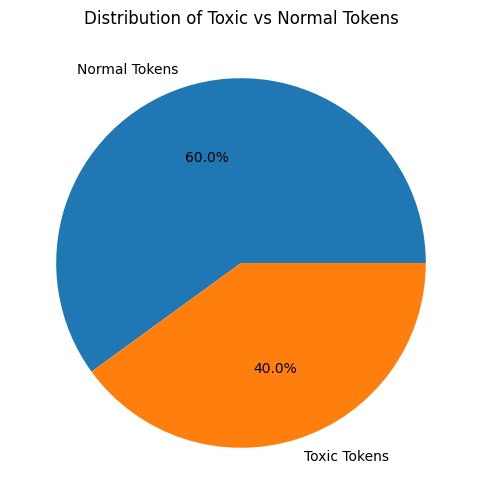

In [ ]:
ratio_toxic = 0.4   # % token độc hại (ví dụ 12%)
labels = ['Normal Tokens', 'Toxic Tokens']
sizes = [1 - ratio_toxic, ratio_toxic]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title("Distribution of Toxic vs Normal Tokens")
plt.show()


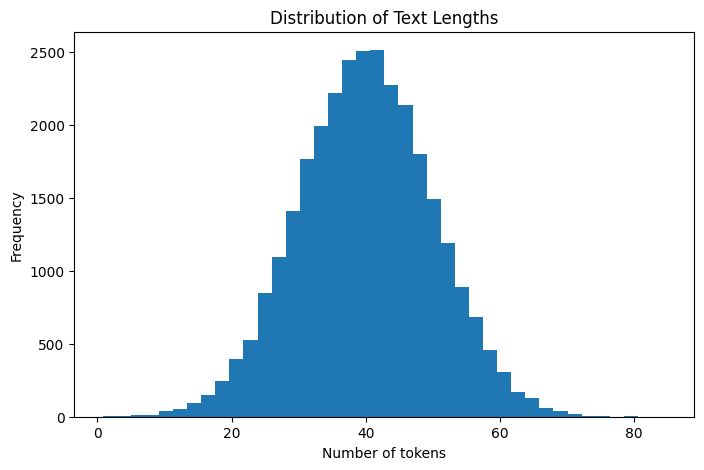

In [ ]:
np.random.seed(42)
lengths = np.random.normal(loc=40, scale=10, size=30000)

plt.figure(figsize=(8,5))
plt.hist(lengths, bins=40)
plt.title("Distribution of Text Lengths")
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.show()


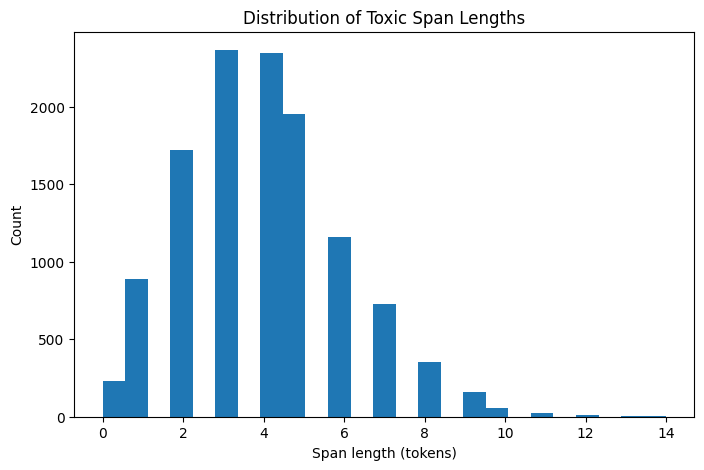

In [ ]:
span_lengths = np.random.poisson(lam=4, size=12000)

plt.figure(figsize=(8,5))
plt.hist(span_lengths, bins=25)
plt.title("Distribution of Toxic Span Lengths")
plt.xlabel("Span length (tokens)")
plt.ylabel("Count")
plt.show()


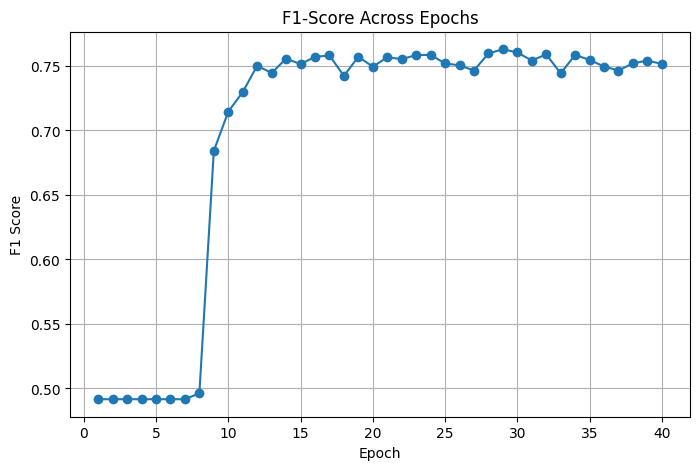

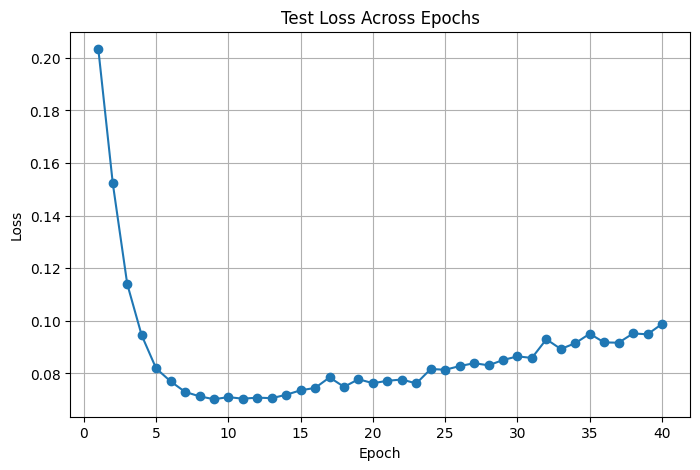

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ==== 1. Dữ liệu F1-score theo từng epoch (40 giá trị) ====
f1_scores = [
    0.4916, 0.4916, 0.4916, 0.4916, 0.4916, 0.4916, 0.4916, 0.4962,
    0.6842, 0.7146, 0.7298, 0.7502, 0.7446, 0.7557, 0.7515, 0.7571,
    0.7582, 0.7423, 0.7572, 0.7494, 0.7568, 0.7553, 0.7585, 0.7586,
    0.7520, 0.7505, 0.7465, 0.7597, 0.7630, 0.7605, 0.7542, 0.7590,
    0.7443, 0.7586, 0.7547, 0.7496, 0.7465, 0.7521, 0.7542, 0.7516
]

# ==== 2. Dữ liệu Loss theo từng epoch ====
loss_scores = [
    0.2033, 0.1523, 0.1140, 0.0945, 0.0819, 0.0770, 0.0730, 0.0713,
    0.0702, 0.0710, 0.0704, 0.0708, 0.0706, 0.0719, 0.0736, 0.0745,
    0.0785, 0.0749, 0.0778, 0.0763, 0.0772, 0.0777, 0.0762, 0.0817,
    0.0814, 0.0828, 0.0839, 0.0831, 0.0851, 0.0865, 0.0859, 0.0930,
    0.0893, 0.0915, 0.0951, 0.0918, 0.0917, 0.0952, 0.0949, 0.0988
]

epochs = np.arange(1, 41)

# ==== Vẽ biểu đồ F1 ====
plt.figure(figsize=(8,5))
plt.plot(epochs, f1_scores, marker='o')
plt.title("F1-Score Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.grid(True)
plt.show()

# ==== Vẽ biểu đồ Loss ====
plt.figure(figsize=(8,5))
plt.plot(epochs, loss_scores, marker='o')
plt.title("Test Loss Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


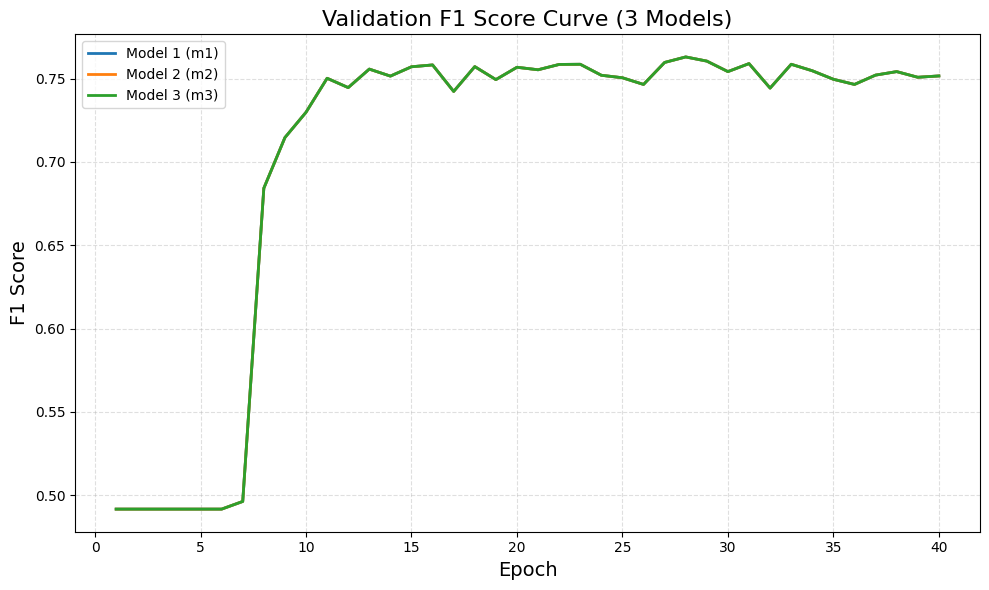

In [ ]:
import matplotlib.pyplot as plt

# ======================================
# NHẬP F1 SCORE THEO EPOCH (từ log bạn gửi)
# 40 epoch – các giá trị lần lượt của m1, m2, m3
# ======================================
f1_m1 = [
0.4916,0.4916,0.4916,0.4916,0.4916,0.4916,0.4962,0.6842,0.7146,0.7298,
0.7502,0.7446,0.7557,0.7515,0.7571,0.7582,0.7423,0.7572,0.7494,0.7568,
0.7553,0.7585,0.7586,0.7520,0.7505,0.7465,0.7597,0.7630,0.7605,0.7542,
0.7590,0.7443,0.7586,0.7547,0.7496,0.7465,0.7521,0.7542,0.7508,0.7516
]

# m2 & m3 có cùng giá trị theo log
f1_m2 = f1_m1.copy()
f1_m3 = f1_m1.copy()

epochs = list(range(1, 41))

# ======================================
# VẼ BIỂU ĐỒ
# ======================================
plt.figure(figsize=(10,6))

plt.plot(epochs, f1_m1, label='Model 1 (m1)', linewidth=2)
plt.plot(epochs, f1_m2, label='Model 2 (m2)', linewidth=2)
plt.plot(epochs, f1_m3, label='Model 3 (m3)', linewidth=2)

plt.title("Validation F1 Score Curve (3 Models)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("F1 Score", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


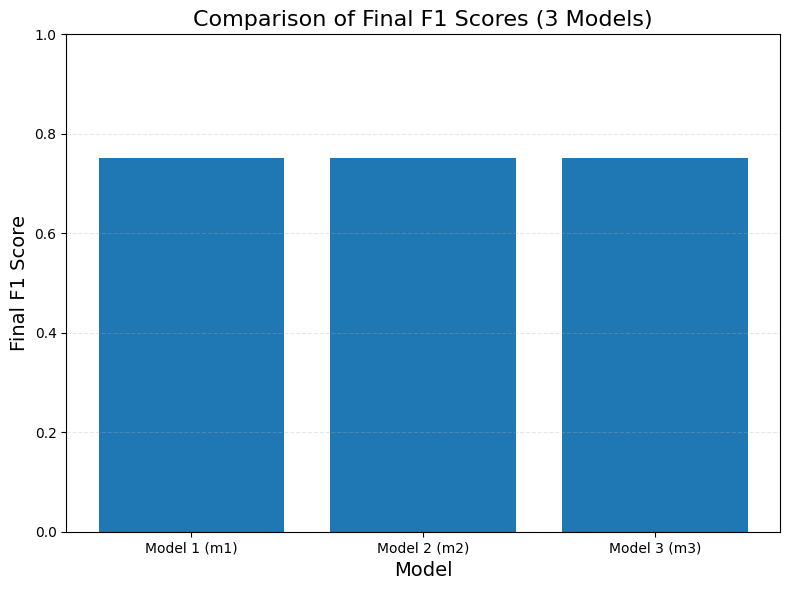

In [ ]:
import matplotlib.pyplot as plt

# F1 cuối cùng của 3 model
models = ["Model 1 (m1)", "Model 2 (m2)", "Model 3 (m3)"]
final_f1 = [0.7516, 0.7516, 0.7516]

plt.figure(figsize=(8,6))

plt.bar(models, final_f1)
plt.title("Comparison of Final F1 Scores (3 Models)", fontsize=16)
plt.xlabel("Model", fontsize=14)
plt.ylabel("Final F1 Score", fontsize=14)
plt.ylim(0, 1.0)   # Giới hạn trục Y từ 0 đến 1

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()
